In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge, Ridge, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [33]:
df = pd.read_excel("ENB2012_data.xlsx")

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [34]:
df.shape

(768, 10)

In [35]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [37]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [38]:
df.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


In [39]:
X = df.iloc[:, 0:8]

y = df["Y1"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [41]:
bayesian_model = BayesianRidge()

bayesian_model.fit(X_train, y_train)

y_pred_bayesian = bayesian_model.predict(X_test)

In [42]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [43]:
robust_model = HuberRegressor()

robust_model.fit(X_train, y_train)

y_pred_robust = robust_model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


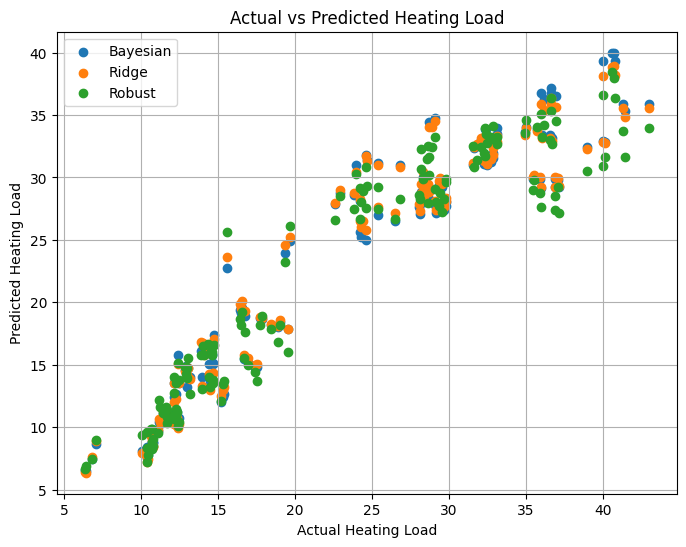

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_bayesian, label="Bayesian")
plt.scatter(y_test, y_pred_ridge, label="Ridge")
plt.scatter(y_test, y_pred_robust, label="Robust")

plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("Actual vs Predicted Heating Load")

plt.legend()
plt.grid(True)

plt.show()

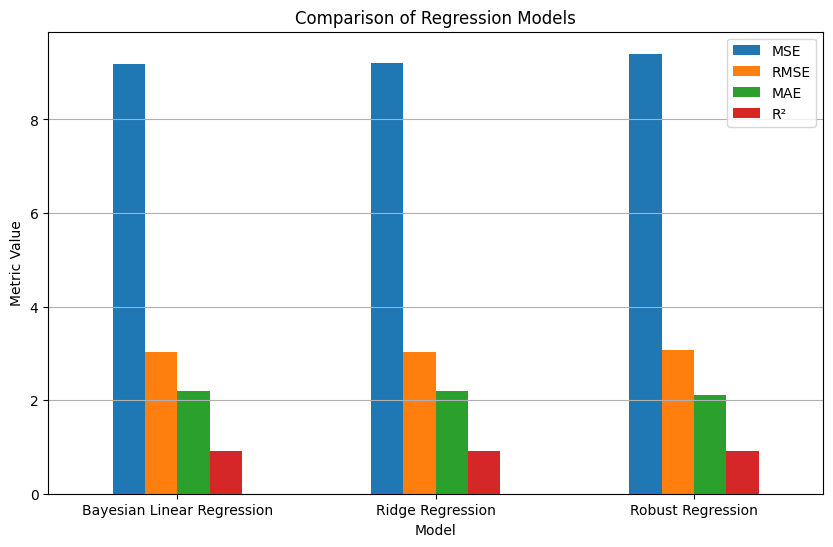

In [45]:
comparison.set_index("Model")[["MSE", "RMSE", "MAE", "R²"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Regression Models")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [46]:
X = df.iloc[:, 0:8]
y = df["Y1"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
bayesian_model = BayesianRidge()

bayesian_model.fit(X_train_scaled, y_train)

y_pred_bayesian = bayesian_model.predict(X_test_scaled)

In [50]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

In [51]:
robust_model = HuberRegressor(max_iter=1000)

robust_model.fit(X_train_scaled, y_train)

y_pred_robust = robust_model.predict(X_test_scaled)

In [52]:
mse_bayesian = mean_squared_error(y_test, y_pred_bayesian)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_robust = mean_squared_error(y_test, y_pred_robust)

print("Bayesian Linear Regression MSE:", round(mse_bayesian, 4))
print("Ridge Regression MSE:", round(mse_ridge, 4))
print("Robust Regression MSE:", round(mse_robust, 4))

Bayesian Linear Regression MSE: 9.1819
Ridge Regression MSE: 9.2138
Robust Regression MSE: 9.4055


In [53]:
rmse_bayesian = np.sqrt(mse_bayesian)
rmse_ridge = np.sqrt(mse_ridge)
rmse_robust = np.sqrt(mse_robust)

print("Bayesian Linear Regression RMSE:", round(rmse_bayesian, 4))
print("Ridge Regression RMSE:", round(rmse_ridge, 4))
print("Robust Regression RMSE:", round(rmse_robust, 4))

Bayesian Linear Regression RMSE: 3.0302
Ridge Regression RMSE: 3.0354
Robust Regression RMSE: 3.0668


In [54]:
mae_bayesian = mean_absolute_error(y_test, y_pred_bayesian)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mae_robust = mean_absolute_error(y_test, y_pred_robust)

print("Bayesian Linear Regression MAE:", round(mae_bayesian, 4))
print("Ridge Regression MAE:", round(mae_ridge, 4))
print("Robust Regression MAE:", round(mae_robust, 4))

Bayesian Linear Regression MAE: 2.1861
Ridge Regression MAE: 2.1908
Robust Regression MAE: 2.1179


In [55]:
r2_bayesian = r2_score(y_test, y_pred_bayesian)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_robust = r2_score(y_test, y_pred_robust)

print("Bayesian Linear Regression R²:", round(r2_bayesian, 4))
print("Ridge Regression R²:", round(r2_ridge, 4))
print("Robust Regression R²:", round(r2_robust, 4))

Bayesian Linear Regression R²: 0.9119
Ridge Regression R²: 0.9116
Robust Regression R²: 0.9098


In [56]:
comparison = pd.DataFrame({
    "Model": [
        "Bayesian Linear Regression",
        "Ridge Regression",
        "Robust Regression"
    ],
    "MSE": [
        mse_bayesian,
        mse_ridge,
        mse_robust
    ],
    "RMSE": [
        rmse_bayesian,
        rmse_ridge,
        rmse_robust
    ],
    "MAE": [
        mae_bayesian,
        mae_ridge,
        mae_robust
    ],
    "R²": [
        r2_bayesian,
        r2_ridge,
        r2_robust
    ]
})

comparison.round(4)

,Model,MSE,RMSE,MAE,R²
0,Bayesian Linear Regression,9.1819,3.0302,2.1861,0.9119
1,Ridge Regression,9.2138,3.0354,2.1908,0.9116
2,Robust Regression,9.4055,3.0668,2.1179,0.9098
